Есакова Елизавета Михайловна

In [ ]:
!pip install -q scikit-learn nltk gensim
!pip install -q pymorphy3


import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap
import torch.nn.functional as F


# скачиваем русские стоп-слова и другие ресурсы nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

https://www.kaggle.com/datasets/laytsw/reviews?resource=download

взяла датасет с кагла с русскими отзывами

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/text/laba2/reviews.csv"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Лабораторная 2. Классификация текста и векторные представления слов

**Охватываемые темы:** логистическая регрессия и классификация текста (4) · эмбеддинги (5) · нейронные сети для текста (6).


### Часть 1 - Классификация текста с TF-IDF (35%)

1. Загрузите датасет для задачи классификации текста. Можете использовать один из:
   - `datasets.load_dataset("imdb")` - анализ тональности отзывов (2 класса).
   - `datasets.load_dataset("ag_news")` - классификация новостей по теме (4 класса).
   - Любой датасет отзывов на русском языке с HuggingFace.

2. **Предобработка текстов:**
   - Приведение к нижнему регистру.
   - Удаление знаков пунктуации.
   - Удаление стоп-слов (`nltk.corpus.stopwords`).
   
   Выведите 3 примера текста до и после обработки.

3. **Признаковое представление - TF-IDF.** Используйте `TfidfVectorizer` из `sklearn`:
   - Объясните формулу TF-IDF своими словами: что такое TF, что такое IDF и зачем их перемножать?
   - Выведите топ слов с наибольшим TF-IDF для каждого класса.

4. Обучите **логистическую регрессию** (`sklearn.linear_model.LogisticRegression`) на TF-IDF матрице. 80% обучение, 20% тест.

5. Вычислите на тесте: accuracy, precision, recall, F1. Постройте confusion matrix.

6. **Анализ ошибок:** найдите 3–5 примеров, на которых модель ошиблась. Попробуйте объяснить, почему.

---

In [ ]:
df = pd.read_csv(ROOT_PATH, sep='\t')
print(f"Загружено {len(df)} отзывов")
print(f"Колонки: {df.columns.tolist()}\n")
print(f"Распределение классов:")
print(df['sentiment'].value_counts())
print(df)

Загружено 90000 отзывов
Колонки: ['review', 'sentiment']

Распределение классов:
sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64
                                                  review sentiment
0      качество плохое пошив ужасный (горловина напер...  negative
1      Товар отдали другому человеку, я не получила п...  negative
2      Ужасная синтетика! Тонкая, ничего общего с пре...  negative
3      товар не пришел, продавец продлил защиту без м...  negative
4          Кофточка голая синтетика, носить не возможно.  negative
...                                                  ...       ...
89995  сделано достаточно хорошо. на ткани сделан рис...  positive
89996  Накидка шикарная. Спасибо большое провдо линяе...  positive
89997  спасибо большое ) продовца рекомендую.. заказа...  positive
89998  Очень довольна заказом! Меньше месяца в РБ.  К...  positive
89999  хорошая куртка. постороннего запаха нет. швы р...  positive

[90000 rows x 2 columns]

In [ ]:
df['label'] = df['sentiment'].map({'negative': 0, 'neautral': 1, 'positive': 2})

print(f"пропуски: {df['label'].isna().sum()}")

пропуски: 0


Вот что входит в список стоп слов:

In [ ]:
rustopwords = set(stopwords.words('russian'))

if 'не' in rustopwords:
    rustopwords.remove('не')

print(rustopwords)

{'после', 'эту', 'с', 'два', 'тут', 'ей', 'всю', 'ней', 'себе', 'ничего', 'больше', 'о', 'мой', 'кто', 'мне', 'они', 'я', 'еще', 'хорошо', 'было', 'у', 'такой', 'да', 'тот', 'ж', 'нет', 'моя', 'меня', 'будто', 'чтобы', 'чтоб', 'его', 'вам', 'сам', 'тоже', 'лучше', 'так', 'опять', 'хоть', 'будет', 'теперь', 'можно', 'когда', 'вас', 'здесь', 'чем', 'об', 'в', 'по', 'какая', 'то', 'без', 'или', 'потом', 'на', 'ее', 'ну', 'если', 'ли', 'куда', 'и', 'нее', 'наконец', 'всего', 'один', 'себя', 'к', 'всех', 'что', 'может', 'чего', 'уж', 'над', 'она', 'все', 'зачем', 'был', 'но', 'три', 'всегда', 'были', 'вот', 'него', 'другой', 'перед', 'потому', 'уже', 'их', 'за', 'из', 'этот', 'только', 'свою', 'ни', 'где', 'ему', 'иногда', 'чуть', 'более', 'мы', 'есть', 'много', 'этого', 'как', 'конечно', 'бы', 'вы', 'нельзя', 'ведь', 'была', 'них', 'впрочем', 'том', 'а', 'до', 'через', 'какой', 'от', 'эти', 'между', 'про', 'разве', 'ты', 'для', 'этой', 'во', 'нас', 'сейчас', 'надо', 'нибудь', 'он', 'никогд

In [ ]:
# добавляем дополнительные русские стоп-слова, которые часто встречаются в отзывах
dop_stopwords = {'это', 'как', 'так', 'же', 'всё', 'весь', 'всего', 'всех', 'очень', 'совсем', 'уже', 'еще', 'ещё', 'такие', 'ладно', 'деньги', 'товар', 'ткань', 'качеств', 'размер', 'заказ', 'пришёл', 'пришел', 'посылку'}

rustopwords.update(dop_stopwords)

def preprocess_russian_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[\W_]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in rustopwords and len(w) >= 2]

    return ' '.join(words)

for i in range(3):
    original = df['review'].iloc[i]
    processed = preprocess_russian_text(original)
    print(f"Как было:\n{original}\n")
    print(f"Мы обработали:\n{processed}\n")

df['clean_review'] = df['review'].apply(preprocess_russian_text)

Как было:
качество плохое пошив ужасный (горловина наперекос) Фото не соответствует Ткань ужасная рисунок блеклый маленький рукав не такой УЖАС!!!!! не стоит за такие деньги г.......

Мы обработали:
качество плохое пошив ужасный горловина наперекос фото не соответствует ужасная рисунок блеклый маленький рукав не ужас не стоит

Как было:
Товар отдали другому человеку, я не получила посылку. Ладно хоть деньги вернули.

Мы обработали:
отдали другому человеку не получила вернули

Как было:
Ужасная синтетика! Тонкая, ничего общего с представленной картинкой, не яркая, рисунок растянут и тусклый, впрочем как и сама кофта- мешок! На картинке кажется приталенной на самом деле нет! Не рекомендую

Мы обработали:
ужасная синтетика тонкая общего представленной картинкой не яркая рисунок растянут тусклый сама кофта мешок картинке кажется приталенной самом деле не рекомендую



# TF-IDF (Term Frequency - Inverse Document Frequency)

Дословно с переводчика: Частота термина - Обратная частота документа

**Term Frequency** - это как часто встречается слово в одном конкретном документе. Считается как число повторений этого слова, деленное на число всех слов в тексте. То есть чем чаще слово в тексте, тем важнее оно для этого текста.

**Inverse Document Frequency** - показывает, насколько слово редкое уже во всем кол-ве документов. Считается как число всех документов, деленное на число документов с этим словом. Если слово встречается в каждом тексте - это значит, что оно не относится к конкретному тексту и не является важным для понятия смысла.

Произведение этих переменных позволяет найти ключевые слова - которые часто используются в конкретном документе, но а в других редко.

Как я поняла, это способ оценить, насколько слово важно для конкретного документа среди других документов.

Если и TF и IDF высокие, то слово является ключевым.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_tfidf = tfidf.fit_transform(df['clean_review'])
y = df['label'].values

print(f"Размер TF-IDF матрицы: {X_tfidf.shape} \n")

feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
tfidf_df['label'] = y

print("10 слов с наибольшим TF-IDF для каждого класса:\n")
for cls_id, cls_name in [(0, 'negative'), (1, 'neautral'), (2, 'positive')]:
    cls_data = tfidf_df[tfidf_df['label']==cls_id]
    cls_mean = cls_data.drop(columns=['label']).mean(numeric_only=True)
    top_words = cls_mean.sort_values(ascending=False).head(10)
    print(f"\n{cls_name.upper()}:")
    for word, score in zip(top_words.index, top_words.values):
        print(f"  {word}: {score:.4f}")

Размер TF-IDF матрицы: (90000, 10000) 

10 слов с наибольшим TF-IDF для каждого класса:


NEGATIVE:
  не: 0.1068
  вернули: 0.0363
  продавец: 0.0290
  не вернули: 0.0286
  спор: 0.0235
  качество: 0.0147
  получила: 0.0146
  не соответствует: 0.0137
  не не: 0.0134
  не получила: 0.0134

NEAUTRAL:
  не: 0.0641
  качество: 0.0222
  вернули: 0.0146
  синтетика: 0.0140
  соответствует: 0.0137
  фото: 0.0123
  не соответствует: 0.0122
  цвет: 0.0119
  платье: 0.0100
  доставка: 0.0098

POSITIVE:
  спасибо: 0.0333
  качество: 0.0255
  супер: 0.0248
  доставка: 0.0247
  не: 0.0237
  отлично: 0.0215
  быстро: 0.0185
  хорошее: 0.0178
  рекомендую: 0.0172
  быстрая: 0.0164


In [ ]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tfidf, y, df.index, test_size=0.2, random_state=2, stratify=y
)

print(f"Обучающая: {X_train.shape[0]}, Тестовая: {X_test.shape[0]}")

lr_tfidf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=2,
    solver='lbfgs'
)

lr_tfidf.fit(X_train, y_train)

Обучающая: 72000, Тестовая: 18000


LogisticRegression(max_iter=1000, random_state=2)

Метрики:

accuracy, precision, recall, F1. Постройте confusion matrix.

In [ ]:
colors = ['#fff0f5', '#ffb6c1', '#ff69b4', '#c71585']
pink = LinearSegmentedColormap.from_list('pink', colors, N=100)

Accuracy: 0.7403

  negative   precision: 0.7326, recall: 0.7032, F1: 0.7176
  neutral    precision: 0.6257, recall: 0.6617, F1: 0.6432
  positive   precision: 0.8711, recall: 0.8560, F1: 0.8635


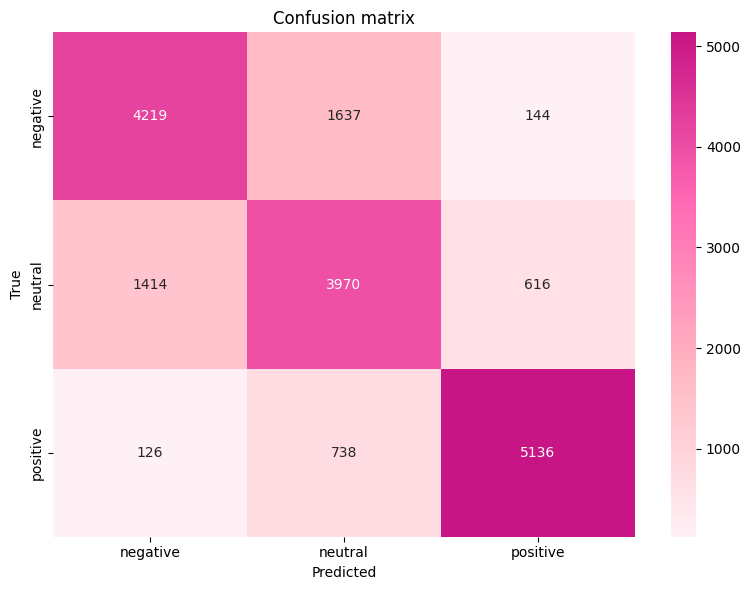

In [ ]:
y_pred = lr_tfidf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

print(f"Accuracy: {acc:.4f}\n")
for i, cls_name in enumerate(['negative', 'neutral', 'positive']):
    print(f"  {cls_name:10s} precision: {prec[i]:.4f}, recall: {rec[i]:.4f}, F1: {f1[i]:.4f}")


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=pink,
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

# Как видно выше, модель предсказывает правильно в 74% случаев, но больше всего она путает нейтральные отзывы с негативными и негативные с нейтральными, и чуть меньше нейтральные с положительными. Негативные с положительными почти не путает.

In [ ]:
errors_mask = y_test != y_pred
error_indices = np.where(errors_mask)[0]

print(f"всего ошибок: {len(error_indices)} из {len(y_test)} ({100*len(error_indices)/len(y_test):.2f}%)\n")

# выводим примеры где произошла ошибка в определении метки
for idx_in_test in error_indices[:4]:
    original_df_index = idx_test[idx_in_test]
    text = df.iloc[original_df_index]['review']
    print(f"текст: {text[:300]}")
    print(f"истинная метка: {['negative', 'neutral', 'positive'][true_label]}")
    print(f"предсказана:   {['negative', 'neutral', 'positive'][pred_label]} \n")

acc_tfidf = acc

всего ошибок: 4675 из 18000 (25.97%)

текст: Платье по размеру, но качество ужасное! Я расстроена! Весь подол с браком - все стыки швов неровные.На фото два боковых шва и один сзади. Платье выглядело интересным за счёт подола, а сейчас наверное обрезать придётся (((
истинная метка: negative
предсказана:   neutral 

текст: Не стоит этих денег совершенно.
истинная метка: negative
предсказана:   neutral 

текст: размер маленький уминя вообще размер M заказал L и маленький
истинная метка: negative
предсказана:   neutral 

текст: плате очень тонкое, синтетика.даже дома ходить в нем не хочется. тело не дышит
истинная метка: negative
предсказана:   neutral 



Как мы видели выше при вывод топа слов с наибольшем TF-IDF для каждого класса, среди них есть повторяющиеся слова. Да и модель плохо различает эмоциональную окраску, так как реагирует на отдельные слова-маркеры, а не понимает человеческую мысль и контекст, по типу иронии, сожаления или сарказма

---

### Часть 2 - Векторные представления слов (35%)

7. Загрузите предобученные **статические эмбеддинги** через `gensim`:
   ```python
   import gensim.downloader as api
   model = api.load("glove-wiki-gigaword-100")
   ```

8. Исследуйте эмбеддинги:
   - Для 5 слов на ваш выбор выведите топ-5 ближайших соседей по косинусному расстоянию.
   - Проверьте аналогию: `king - man + woman = ?`. Вычислите через `model.most_similar(positive=["king", "woman"], negative=["man"])`. Объясните, что означает векторная арифметика в данном случае. *Можно заменить на другие известные примеры.

9. Выберите 4–5 тематических группы слов (например: животные, страны, профессии, эмоции) по 8-10 слов в каждой. Получите их эмбеддинги и визуализируйте через **t-SNE** (`sklearn.manifold.TSNE`). Раскрасьте точки по группам. Прокомментируйте: образуют ли слова кластеры?

10. **Классификация с усреднёнными эмбеддингами:** для каждого текста из датасета вычислите средний вектор по всем словам. Обучите логистическую регрессию на этих векторах. Сравните accuracy с результатом из 1 части.

---

https://www.nltk.org/howto/gensim.html

информация про работу модели

In [ ]:
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-100")

# обучен на английской википедии

In [ ]:
print(f"размерность вектора: {model.vector_size}")

размерность вектора: 100


In [ ]:
words_to_check = ["mushroom", "kettle", "university", "excellent", "barrette"]

In [ ]:
print("5 ближайших соседей по косинусному расстоянию:\n")

for word in words_to_check:
    if word in model:
        neighbors = model.most_similar(word, topn=5)
        neighbors_str = ", ".join([f"{w}({s:.7f})" for w, s in neighbors])
        print(f" {word:10s} : {neighbors_str}")
    else:
        print(f" {word:10s} - не найдено в словаре")

5 ближайших соседей по косинусному расстоянию:

 mushroom   : mushrooms(0.7260389), tomato(0.6131451), shiitake(0.6131117), truffle(0.5931091), onion(0.5895049)
 kettle     : pot(0.5874345), kettles(0.5863330), fork(0.5321534), boiling(0.5200309), lobster(0.5085292)
 university : college(0.8294213), harvard(0.8156034), yale(0.8113803), professor(0.8103785), graduate(0.7993001)
 excellent  : good(0.7936238), quality(0.7606269), terrific(0.7415624), superb(0.7402959), best(0.7287570)
 barrette   : zogg(0.6133286), permed(0.6013698), lavette(0.5922495), pomade(0.5869138), unibrow(0.5821418)


In [ ]:
model.most_similar(positive=["king", "woman"], negative=["man"])

[('queen', 0.7698540687561035),
 ('monarch', 0.6843381524085999),
 ('throne', 0.6755736470222473),
 ('daughter', 0.6594556570053101),
 ('princess', 0.6520534157752991),
 ('prince', 0.6517034769058228),
 ('elizabeth', 0.6464517712593079),
 ('mother', 0.631171703338623),
 ('emperor', 0.6106470823287964),
 ('wife', 0.6098655462265015)]

Векторные эмбеддинги кодируют семантику слов в виде направлений в пространстве.

То есть тут из вектора 'король' мы вычитаем вектор 'мужчина', убирая мужской пол. У нас остается только то, что это 'власть/королевская особь'. И мы добавляем вектор 'женщина', и получаем 'женщина с властью' или 'королевская особь женского пола', что как раз и есть 'королева'

по итогу этот метод ищет по косинусному расстоянию векторы в модели, которые находятся ближе всего к полученному результирующему вектору. Косинусное расстояние показывает насколько два вектора указывают в одном направлении, измеряя косинус угла между ними

In [ ]:
model.most_similar(positive=["cat", "dog"], negative=["wild"])

[('puppy', 0.6852957606315613),
 ('pet', 0.64664626121521),
 ('dogs', 0.6068797707557678),
 ('monkey', 0.5911524295806885),
 ('kitten', 0.5761268734931946),
 ('poodle', 0.5692161917686462),
 ('hound', 0.5677886605262756),
 ('rat', 0.558797299861908),
 ('kennel', 0.5528702139854431),
 ('pig', 0.5503626465797424)]

Как и ранее, тут ищутся слова, похожие на 'кошка' и 'собака', но мы убираем компоненту дикости, по идее должны вывестись небольшие пушистые домашние животные и все, что с ними связано. Возможно слово 'обезьяна' тут выдалось потому, что оно не часто упоминается в контексте диких животных, а больше связано с цирками/зоопарками, поэтому оказалось в этом списке.

In [ ]:
Tema_groupi = {
    "Животные": ["dog", "cat", "horse", "hamster", "tiger", "lion", "rabbit", "wolf","bear", "eagle"],

    "Страны": ["russia", "brazil", "france", "germany", "italy", "china", "japan", "canada", "spain", "india"],

    "Профессии": ["doctor", "teacher", "engineer", "lawyer", "artist", "scientist", "driver", "chef", "pilot", "manager"],

    "Эмоции": ["joy", "anger", "sadness", "fear", "love", "hate", "surprise", "happiness", "anxiety", "peace"]}

Общее количество точек для визуализации: 40



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


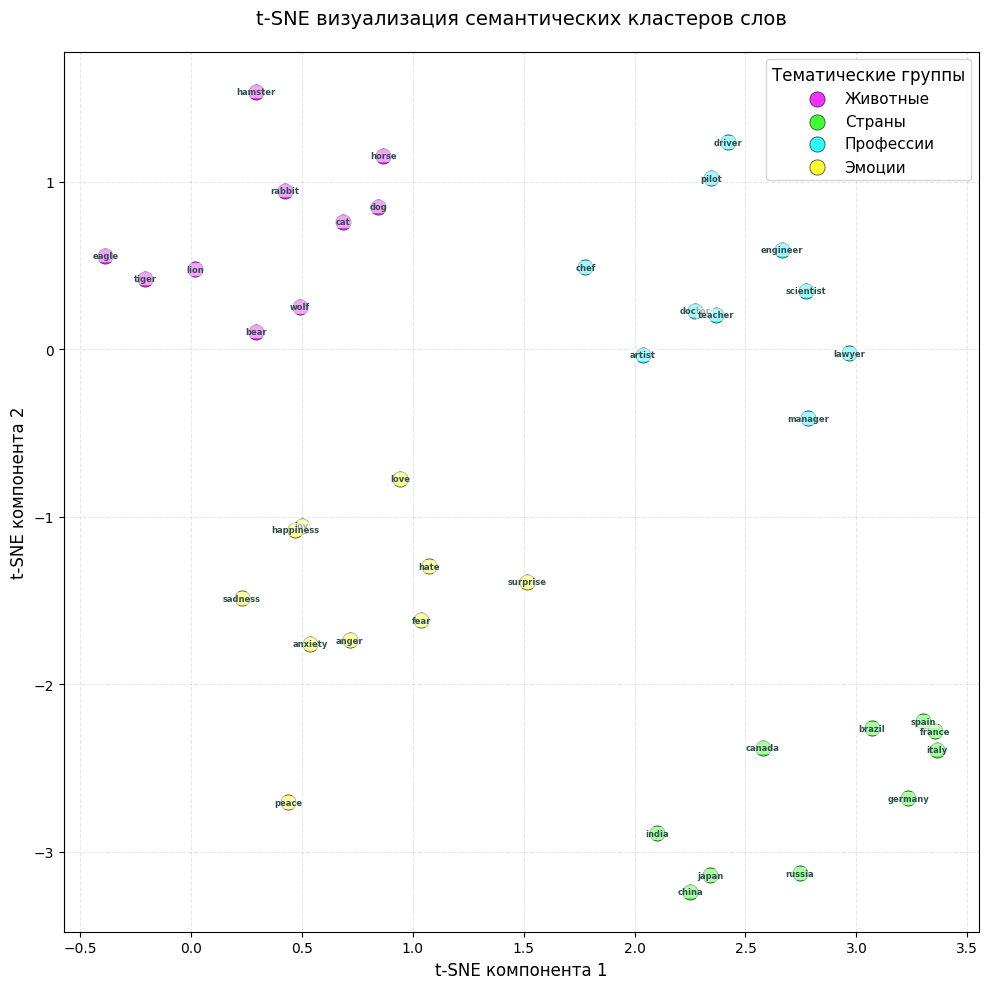

In [ ]:
vectors = []
labels = []
words_list = []

for group_name, words in Tema_groupi.items():
    found = 0
    for word in words:
        if word in model:
            vectors.append(model[word])
            labels.append(group_name)
            words_list.append(word)


vectors = np.array(vectors)
print(f"Общее количество точек для визуализации: {len(vectors)}\n")

tsne = TSNE(
    n_components=2,
    perplexity=25,
    random_state=42,
    n_iter=1000,
    learning_rate='auto',
    init='pca'
)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 10))
colors = {
    "Животные": "#ea00ff",
    "Страны": "#11ff00",
    "Профессии": "#00f7ff",
    "Эмоции": "#fbff00"
}

all_words = []
word_to_group = {}
for group, words in Tema_groupi.items():
    for word in words:
        all_words.append(word)
        word_to_group[word] = group


for group_name in Tema_groupi.keys():
    mask = np.array(labels) == group_name
    plt.scatter(
        vectors_2d[mask, 0],
        vectors_2d[mask, 1],
        c=colors[group_name],
        label=group_name,
        s=120,
        alpha=0.8,
        edgecolors='black',
        linewidth=0.5
    )

for i, word in enumerate(words_list):
    x, y = vectors_2d[i]
    plt.text(x, y, word,
             fontsize=6,
             ha='center', va='center',
             fontweight='bold',
             color='darkslategray',
             bbox=dict(facecolor='white', alpha=0.55, edgecolor='none', pad=1.5))

plt.legend(title="Тематические группы", fontsize=11, title_fontsize=12)
plt.title("t-SNE визуализация семантических кластеров слов", fontsize=14, pad=20)
plt.xlabel("t-SNE компонента 1", fontsize=12)
plt.ylabel("t-SNE компонента 2", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Слова, которые встречаются в похожих контекстах, получают похожие векторы. Это происходит потому, что семантически близкие слова имеют близкие векторные представления в исходном пространстве.

Кластеры разделяются хорошо, а это значит, что эмбеддинги захватили
тематическую структуру языка. Векторные представления слов действительно кодируют их смысл - слова из одной категории как раз имеют похожие векторы и поэтому располагаются близко в пространстве эмбеддингов. Небольшие пересечения возможны из-за того, что есть разные слова с очень похожим значением по смыслу(как happines и joy)


In [ ]:
def text_to_avg_vec_glove(text, w2v_model):
    words = str(text).lower().split()
    vecs = []
    for word in words:
        word_clean = re.sub(r'[^\w]', '', word)
        if word_clean in w2v_model:
            vecs.append(w2v_model[word_clean])

    if not vecs:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X_glove_avg = np.array([text_to_avg_vec_glove(text, model) for text in df['clean_review']])

y = df['label'].values

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_glove_avg, y, test_size=0.2, random_state=42, stratify=y
)

lr_glove = LogisticRegression(max_iter=1000, random_state=42)
lr_glove.fit(X_train_g, y_train_g)

y_pred_glove = lr_glove.predict(X_test_g)
acc_glove_avg = accuracy_score(y_test_g, y_pred_glove)

print(f"accuracy glove: {acc_glove_avg:.10f}")
print(f"accuracy TF-IDF: {acc_tfidf:.10f}")
print(f"Разница: {acc_tfidf - acc_glove_avg:.10f}")

accuracy glove: 0.5146666667
accuracy TF-IDF: 0.7402777778
Разница: 0.2256111111


# При усреднении векторов всех слов теряется информация о порядке слов и их взаимном расположении, некоторые слова могут усредниться и по итогу поменять тональность на нейтральную, также некоторые слова из отзывов могут отсутствовать в предобученной модели glove, поэтому точность и ниже, чем у TF-IDF

---

### Часть 3 - Нейронная сеть для классификации текста (30%)

11. Постройте **простую нейронную сеть для классификации текста** на PyTorch или Keras:

    Архитектура:
    - `Embedding` слой (инициализируйте случайно или предобученными GloVe весами).
    - `GlobalAveragePooling` - усредняет эмбеддинги всех токенов в одном векторе.
    - Полносвязный слой с активацией ReLU.
    - Выходной слой (sigmoid для бинарной задачи / softmax для многоклассовой).

12. Обучите модель (10–20 эпох). Постройте графики loss и accuracy на train и val.

13. Сравните два варианта:
    - Embedding слой инициализирован **случайно** (обучается с нуля).
    - Embedding слой инициализирован предобученными **GloVe весами** (заморожен, не обновляется).
    
    Запишите accuracy на тесте. Объясните разницу.

14. Заполните итоговую таблицу:

    | Метод | Представление текста | Test Accuracy |
    |---|---|---|
    | Логистическая регрессия | TF-IDF | |
    | Логистическая регрессия | Усреднённые GloVe | |
    | Нейросеть | Random Embedding | |
    | Нейросеть | GloVe (заморожен) | |

    Какой метод оказался лучшим? Чем вы это объясняете?

---

In [ ]:
vocab = tfidf.vocabulary_
vocab_size = len(vocab)
max_len = 200

def text_to_indices(text, vocab, max_len=200):
    words = text.lower().split()
    ids = [vocab.get(w, 0) for w in words][:max_len]
    return ids + [0] * (max_len - len(ids))

print("Кодирование текстов в индексы")
X_seq = np.array([text_to_indices(t, vocab, max_len) for t in df['clean_review']])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=2, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=2, stratify=y_train
)

def make_loader(X, y, batch=64, shuffle=False):
    X_t = torch.LongTensor(X)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val, y_val)
test_loader  = make_loader(X_test, y_test)

num_classes = len(np.unique(y))
print(f"Число классов: {num_classes}, размер словаря: {vocab_size}")

Кодирование текстов в индексы
Число классов: 3, размер словаря: 10000


In [ ]:
class TextNet(nn.Module):

    def __init__(self, vocab_size, embed_dim=100, num_classes=3,
                 pretrained_weights=None, freeze_emb=False):
        super().__init__()

        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if pretrained_weights is not None:
            self.emb.weight.data.copy_(torch.from_numpy(pretrained_weights))
            if freeze_emb:
                self.emb.weight.requires_grad = False
        self.fc1 = nn.Linear(embed_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        e = self.emb(x)
        mask = (x != 0).float().unsqueeze(-1)
        e = e * mask
        sum_e = e.sum(dim=1)
        count = mask.sum(dim=1).clamp(min=1)
        pooled = sum_e / count

        h = torch.relu(self.fc1(pooled))
        out = self.fc2(h)
        return F.log_softmax(out, dim=1)

In [ ]:
glove_weights = np.zeros((vocab_size, 100))
oov = 0
for w, idx in vocab.items():
    if w in model:
        glove_weights[idx] = model[w]
    else:
        glove_weights[idx] = np.random.normal(0, 0.1, 100)
        oov += 1
print(f"OOV слов: {oov}/{vocab_size} ({100*oov/vocab_size:.1f}%)")

OOV слов: 9645/10000 (96.5%)


In [ ]:
def train_model(model, epochs=15, lr=0.001, name=""):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss, tr_corr, tr_tot = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
            tr_corr += (out.argmax(1) == yb).sum().item()
            tr_tot  += xb.size(0)

        model.eval()
        va_loss, va_corr, va_tot = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                va_loss += loss.item() * xb.size(0)
                va_corr += (out.argmax(1) == yb).sum().item()
                va_tot  += xb.size(0)

        hist['train_loss'].append(tr_loss / tr_tot)
        hist['train_acc'].append(tr_corr / tr_tot)
        hist['val_loss'].append(va_loss / va_tot)
        hist['val_acc'].append(va_corr / va_tot)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} - "
                  f"Train: loss={tr_loss/tr_tot:.4f} acc={tr_corr/tr_tot:.4f} | "
                  f"Val: loss={va_loss/va_tot:.4f} acc={va_corr/va_tot:.4f}")

    return hist, model, device

# Функция оценки на тесте
def evaluate(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return accuracy_score(labels, preds)

In [ ]:
torch.manual_seed(2)
net_random = TextNet(vocab_size, embed_dim=100, num_classes=num_classes)
hist_r, net_random, dev = train_model(net_random, epochs=15, lr=1e-3)
acc_random = evaluate(net_random, test_loader, dev)
print(f"Точность Random Embedding: {acc_random:.4f}")

Epoch 01 - Train: loss=0.7597 acc=0.6517 | Val: loss=0.6733 acc=0.7025
Epoch 05 - Train: loss=0.5389 acc=0.7669 | Val: loss=0.6291 acc=0.7253
Epoch 10 - Train: loss=0.4627 acc=0.8045 | Val: loss=0.6722 acc=0.7194
Epoch 15 - Train: loss=0.3870 acc=0.8433 | Val: loss=0.7600 acc=0.7156
Точность Random Embedding: 0.7116


In [ ]:
torch.manual_seed(2)
net_glove = TextNet(vocab_size, embed_dim=100, num_classes=num_classes,
                    pretrained_weights=glove_weights, freeze_emb=True)
hist_g, net_glove, _ = train_model(net_glove, epochs=15, lr=1e-3)
acc_glove_frozen = evaluate(net_glove, test_loader, dev)
print(f"Точность GloVe (заморожен): {acc_glove_frozen:.4f}")

Epoch 01 - Train: loss=0.9369 acc=0.5387 | Val: loss=0.8940 acc=0.5720
Epoch 05 - Train: loss=0.8490 acc=0.6017 | Val: loss=0.8526 acc=0.5985
Epoch 10 - Train: loss=0.8203 acc=0.6174 | Val: loss=0.8334 acc=0.6114
Epoch 15 - Train: loss=0.7983 acc=0.6298 | Val: loss=0.8182 acc=0.6175
Точность GloVe (заморожен): 0.6274


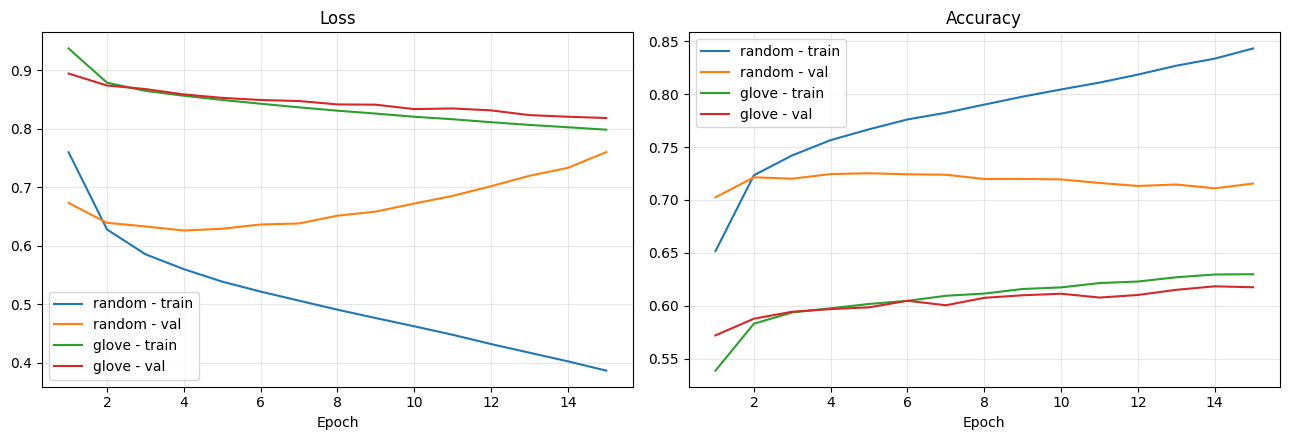

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, 16)

axes[0].plot(epochs, hist_r['train_loss'], label='random - train')
axes[0].plot(epochs, hist_r['val_loss'],  label='random - val')
axes[0].plot(epochs, hist_g['train_loss'], label='glove - train')
axes[0].plot(epochs, hist_g['val_loss'],  label='glove - val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs, hist_r['train_acc'], label='random - train')
axes[1].plot(epochs, hist_r['val_acc'],   label='random - val')
axes[1].plot(epochs, hist_g['train_acc'], label='glove - train')
axes[1].plot(epochs, hist_g['val_acc'], label='glove - val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

Random Embedding работает лучше, потому что модель сама изучает семантику слов под мою задачу на русских отзывах. Даже если в тексте встречаются редкие/специфичные слова, их векторы постепенно подстраиваются под контекст.

Но как видно на графиках, модель просто запоминает конкретные слова и их метки, а не выучивает обобщаемые признаки, из-за этого на тестовой выборке начинают расти потери и падать точность

При glove модель получает на вход почти белый шум и пытается на его основе обучить два полносвязных слоя. Так как мы загружали glove-wiki-gigaword-100, который обучен на английской википедии, то большую часть выборки по итогу занимают случайные векторы. У мен таких слов оченб много - 96%, потому что в отзывах таких слов много из за того, что это может быть опечатки(как было в примерах ранее). Из-а этого значительная часть данных становится просто шумом.

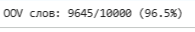

Но точность почему-то стала расти, возможно модель уловила какой-то очень грубый дисбаланс классов или случайные совпадения длины текста, а не смысл


In [ ]:
results = pd.DataFrame({
    'Метод': ['ЛогРег', 'ЛогРег', 'нейронка', 'нейронка'],
    'Представление текста': ['TF-IDF','усреднённые glove', 'random','glove замороженный'],
    'Test Accuracy': [f'{acc_tfidf:.6f}', f'{acc_glove_avg:.6f}',
                      f'{acc_random:.6f}', f'{acc_glove_frozen:.6f}']})
print(results.to_string(index=False))

best_idx = np.argmax([acc_tfidf, acc_glove_avg, acc_random, acc_glove_frozen])
best = results.iloc[best_idx]

print(f"Лучший метод: {best['Метод']} + {best['Представление текста']}")

   Метод Представление текста Test Accuracy
  ЛогРег               TF-IDF      0.740278
  ЛогРег    усреднённые glove      0.514667
нейронка               random      0.711611
нейронка   glove замороженный      0.627389
Лучший метод: ЛогРег + TF-IDF


Этот метод стал лучшим, потому что TF-IDF выделяет ключевые слова для каждого класса, игнорируя стоп-слова и частую лексику. И по итогу это лучше отражает суть моей задачи по классификации отзывов, потому что слова, присущие конкретному классу, имеют больший вес.

А вот словарь Glove не покрывает особенности моей задачи и из-за того, что мы ее заморозили, то модель не смогла подстроиться и результат вышел неудовлетворительный

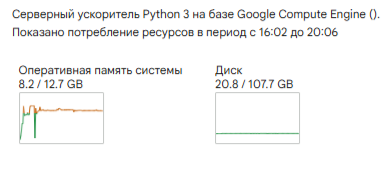

Все выполнение работы заняло около 8 гб ОЗУ